In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import time
import copy
from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_recall_fscore_support
)

torch.manual_seed(42)
np.random.seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

CIFAR10_CLASSES = ['airplane','automobile','bird','cat','deer',
                   'dog','frog','horse','ship','truck']

Using device: cuda


In [2]:
MEAN = (0.4914, 0.4822, 0.4465)
STD  = (0.2023, 0.1994, 0.2010)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

# Download both versions of training data
full_train        = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                  download=True,  transform=train_transform)
full_train_notaug = torchvision.datasets.CIFAR10(root='./data', train=True,
                                                  download=False, transform=test_transform)
test_set          = torchvision.datasets.CIFAR10(root='./data', train=False,
                                                  download=True,  transform=test_transform)

# Generate ONE set of indices and reuse for both — fixes the leakage
torch.manual_seed(42)
indices       = torch.randperm(50000).tolist()
train_indices = indices[:40000]
val_indices   = indices[40000:]

# Subset both datasets using the SAME indices
train_set      = torch.utils.data.Subset(full_train,        train_indices)
val_set_notaug = torch.utils.data.Subset(full_train_notaug, val_indices)

BATCH_SIZE = 128
train_loader = torch.utils.data.DataLoader(train_set,      batch_size=BATCH_SIZE,
                                            shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = torch.utils.data.DataLoader(val_set_notaug, batch_size=BATCH_SIZE,
                                            shuffle=False, num_workers=2, pin_memory=True)
test_loader  = torch.utils.data.DataLoader(test_set,       batch_size=BATCH_SIZE,
                                            shuffle=False, num_workers=2, pin_memory=True)

print(f"Train: {len(train_set)} | Val: {len(val_set_notaug)} | Test: {len(test_set)}")

Train: 40000 | Val: 10000 | Test: 10000


In [3]:
class PlainCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(PlainCNN, self).__init__()

        # Block 1: 3 -> 64, spatial 32->16
        self.conv1 = nn.Conv2d(3,  64, kernel_size=3, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(64)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(64)
        self.pool1 = nn.MaxPool2d(2, 2)   # 32 -> 16

        # Block 2: 64 -> 128, spatial 16->8
        self.conv3 = nn.Conv2d(64,  128, kernel_size=3, padding=1, bias=False)
        self.bn3   = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1, bias=False)
        self.bn4   = nn.BatchNorm2d(128)
        self.pool2 = nn.MaxPool2d(2, 2)   # 16 -> 8

        # Block 3: 128 -> 256, spatial 8->4
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1, bias=False)
        self.bn5   = nn.BatchNorm2d(256)
        self.conv6 = nn.Conv2d(256, 256, kernel_size=3, padding=1, bias=False)
        self.bn6   = nn.BatchNorm2d(256)
        self.pool3 = nn.MaxPool2d(2, 2)   # 8 -> 4

        # Global Average Pooling: 4x4 -> 1x1
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(0.3)

        # Classifier head
        self.fc = nn.Linear(256, num_classes)

    def forward(self, x):
        # Block 1
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)

        # Block 2
        x = F.relu(self.bn3(self.conv3(x)))
        x = F.relu(self.bn4(self.conv4(x)))
        x = self.pool2(x)

        # Block 3
        x = F.relu(self.bn5(self.conv5(x)))
        x = F.relu(self.bn6(self.conv6(x)))
        x = self.pool3(x)

        # GAP + classify
        x = self.gap(x)
        x = x.view(x.size(0), -1)   # flatten to (batch, 256)
        x = self.drop(x)
        x = self.fc(x)
        return x

# Quick parameter count
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

plain_cnn = PlainCNN().to(DEVICE)
print(f"PlainCNN parameters: {count_params(plain_cnn):,} ({count_params(plain_cnn)/1000:.1f}k)")

PlainCNN parameters: 1,148,874 (1148.9k)


In [4]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()

        # Main path
        self.conv1 = nn.Conv2d(in_channels, out_channels,
                               kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)

        self.conv2 = nn.Conv2d(out_channels, out_channels,
                               kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        # Shortcut path: identity if same shape, 1x1 conv otherwise
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        # Main path: Conv->BN->ReLU->Conv->BN
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        # Add skip connection BEFORE final ReLU
        out = out + self.shortcut(x)
        out = F.relu(out)
        return out


class ResidualCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(ResidualCNN, self).__init__()

        # Stem: initial conv before residual stages
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )

        # Stage 1: 64 channels, no downsampling
        self.stage1 = nn.Sequential(
            ResidualBlock(64, 64, stride=1),
            ResidualBlock(64, 64, stride=1)
        )

        # Stage 2: 128 channels, downsample with stride=2
        self.stage2 = nn.Sequential(
            ResidualBlock(64,  128, stride=2),
            ResidualBlock(128, 128, stride=1)
        )

        # Stage 3: 256 channels, downsample with stride=2
        self.stage3 = nn.Sequential(
            ResidualBlock(128, 256, stride=2),
            ResidualBlock(256, 256, stride=1)
        )

        # Global Average Pooling + classifier
        self.gap  = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(0.3)
        self.fc   = nn.Linear(256, num_classes)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.drop(x)
        x = self.fc(x)
        return x

res_cnn = ResidualCNN().to(DEVICE)
print(f"ResidualCNN parameters: {count_params(res_cnn):,} ({count_params(res_cnn)/1000:.1f}k)")

ResidualCNN parameters: 2,777,674 (2777.7k)


In [5]:
def train_model(model, train_loader, val_loader, epochs=50,
                lr=1e-3, weight_decay=1e-4, model_name='model'):
    """
    Trains model with AdamW + OneCycleLR.
    Returns history dict with per-epoch metrics.
    """
    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr,
                                   weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=lr * 10,
        steps_per_epoch=len(train_loader),
        epochs=epochs,
        pct_start=0.3
    )

    history = {'train_loss': [], 'val_loss': [],
               'train_acc':  [], 'val_acc':  []}

    best_val_acc  = 0.0
    best_weights  = None
    start_time    = time.time()

    for epoch in range(epochs):
        # ── Training phase ──
        model.train()
        running_loss = 0.0
        correct = total = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss    = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted  = outputs.max(1)
            total        += labels.size(0)
            correct      += predicted.eq(labels).sum().item()

        train_loss = running_loss / total
        train_acc  = 100. * correct / total

        # ── Validation phase ──
        model.eval()
        val_loss_sum = 0.0
        val_correct = val_total = 0

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
                outputs  = model(inputs)
                loss     = criterion(outputs, labels)
                val_loss_sum += loss.item() * inputs.size(0)
                _, predicted  = outputs.max(1)
                val_total    += labels.size(0)
                val_correct  += predicted.eq(labels).sum().item()

        val_loss = val_loss_sum / val_total
        val_acc  = 100. * val_correct / val_total

        # Save best weights
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if (epoch + 1) % 10 == 0:
            gap = train_acc - val_acc
            print(f"[{model_name}] Epoch {epoch+1:3d}/{epochs} | "
                  f"Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}% | "
                  f"Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}% | "
                  f"Gap: {gap:.2f}%")

    elapsed = (time.time() - start_time) / 60
    print(f"\n[{model_name}] Training complete in {elapsed:.2f} min")
    print(f"[{model_name}] Best Val Acc: {best_val_acc:.2f}%")

    # Restore best weights
    model.load_state_dict(best_weights)
    history['training_time_min'] = elapsed
    history['best_val_acc']      = best_val_acc
    return model, history

In [6]:
def evaluate_model(model, loader):
    """Returns test accuracy, all predictions, all true labels."""
    model.eval()
    all_preds  = []
    all_labels = []
    correct = total = 0

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = 100. * correct / total
    return acc, np.array(all_preds), np.array(all_labels)

In [7]:
# Plain CNN
torch.manual_seed(42)
plain_cnn = PlainCNN().to(DEVICE)

plain_cnn, plain_history = train_model(
    plain_cnn, train_loader, val_loader,
    epochs=40, lr=0.001, model_name='PlainCNN'
)

plain_test_acc, plain_preds, plain_labels = evaluate_model(plain_cnn, test_loader)
plain_gap = plain_history['train_acc'][-1] - plain_history['val_acc'][-1]
print(f"\nPlainCNN Test Accuracy: {plain_test_acc:.2f}%")
print(f"PlainCNN Overfitting Gap (final epoch): {plain_gap:.2f}%")

[PlainCNN] Epoch  10/40 | Train Loss: 0.5031 Acc: 82.79% | Val Loss: 0.5318 Acc: 82.77% | Gap: 0.02%
[PlainCNN] Epoch  20/40 | Train Loss: 0.2758 Acc: 90.38% | Val Loss: 0.4466 Acc: 86.43% | Gap: 3.95%
[PlainCNN] Epoch  30/40 | Train Loss: 0.1077 Acc: 96.23% | Val Loss: 0.3483 Acc: 90.81% | Gap: 5.42%
[PlainCNN] Epoch  40/40 | Train Loss: 0.0405 Acc: 98.71% | Val Loss: 0.3623 Acc: 91.81% | Gap: 6.90%

[PlainCNN] Training complete in 22.02 min
[PlainCNN] Best Val Acc: 91.81%

PlainCNN Test Accuracy: 90.94%
PlainCNN Overfitting Gap (final epoch): 6.90%


In [8]:
# Resicual CNN
torch.manual_seed(42)
res_cnn = ResidualCNN().to(DEVICE)

res_cnn, res_history = train_model(
    res_cnn, train_loader, val_loader,
    epochs=40, lr=0.001, model_name='ResidualCNN'
)

res_test_acc, res_preds, res_labels = evaluate_model(res_cnn, test_loader)
res_gap = res_history['train_acc'][-1] - res_history['val_acc'][-1]
print(f"\nResidualCNN Test Accuracy: {res_test_acc:.2f}%")
print(f"ResidualCNN Overfitting Gap (final epoch): {res_gap:.2f}%")

[ResidualCNN] Epoch  10/40 | Train Loss: 0.4882 Acc: 83.17% | Val Loss: 0.4837 Acc: 83.98% | Gap: -0.81%
[ResidualCNN] Epoch  20/40 | Train Loss: 0.2463 Acc: 91.57% | Val Loss: 0.3579 Acc: 88.97% | Gap: 2.60%
[ResidualCNN] Epoch  30/40 | Train Loss: 0.0711 Acc: 97.50% | Val Loss: 0.3164 Acc: 91.90% | Gap: 5.59%
[ResidualCNN] Epoch  40/40 | Train Loss: 0.0163 Acc: 99.45% | Val Loss: 0.3428 Acc: 93.23% | Gap: 6.22%

[ResidualCNN] Training complete in 26.10 min
[ResidualCNN] Best Val Acc: 93.25%

ResidualCNN Test Accuracy: 92.45%
ResidualCNN Overfitting Gap (final epoch): 6.22%


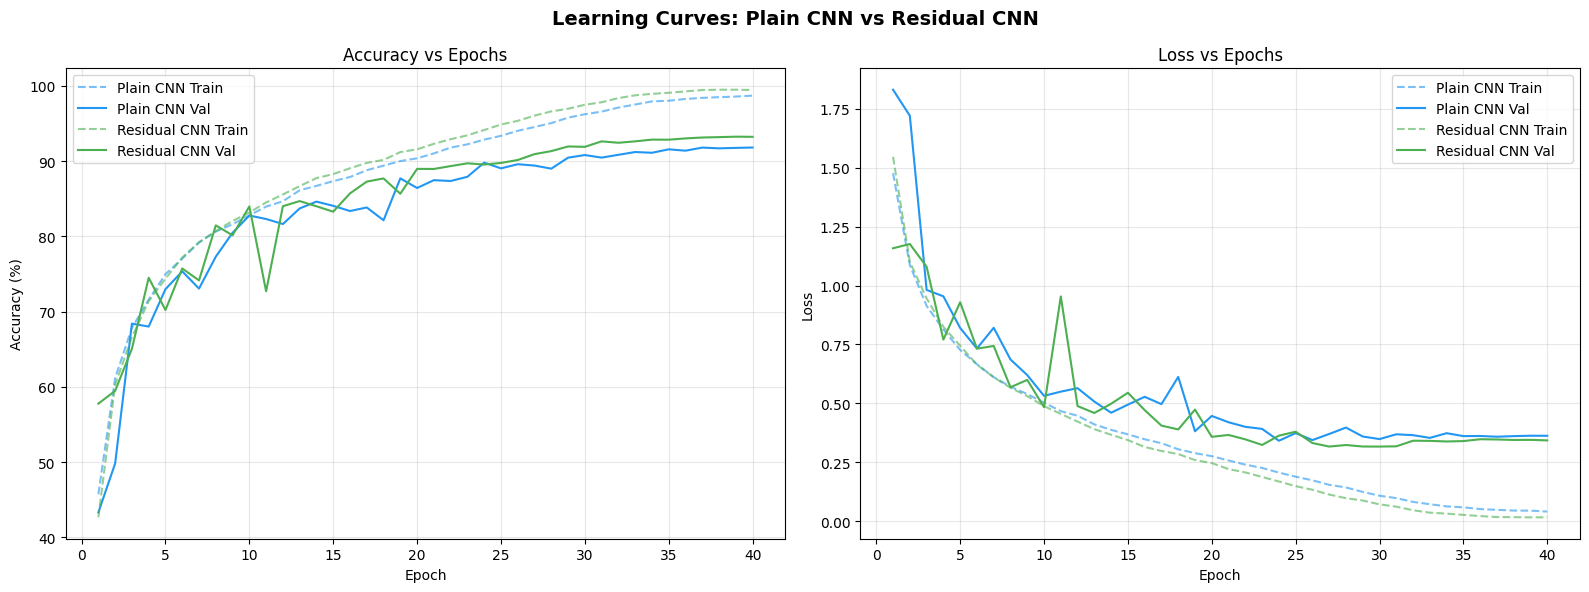

In [9]:
# Plotting the learnig curves
epochs_range = range(1, len(plain_history['train_acc']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Learning Curves: Plain CNN vs Residual CNN',
             fontsize=14, fontweight='bold')

colors = {'Plain CNN': '#2196F3', 'Residual CNN': '#4CAF50'}

# Accuracy plot
ax = axes[0]
ax.plot(epochs_range, plain_history['train_acc'], '--', color=colors['Plain CNN'],  alpha=0.6, label='Plain CNN Train')
ax.plot(epochs_range, plain_history['val_acc'],   '-',  color=colors['Plain CNN'],  label='Plain CNN Val')
ax.plot(epochs_range, res_history['train_acc'],   '--', color=colors['Residual CNN'], alpha=0.6, label='Residual CNN Train')
ax.plot(epochs_range, res_history['val_acc'],     '-',  color=colors['Residual CNN'], label='Residual CNN Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.set_title('Accuracy vs Epochs'); ax.legend(); ax.grid(alpha=0.3)

# Loss plot
ax = axes[1]
ax.plot(epochs_range, plain_history['train_loss'], '--', color=colors['Plain CNN'],  alpha=0.6, label='Plain CNN Train')
ax.plot(epochs_range, plain_history['val_loss'],   '-',  color=colors['Plain CNN'],  label='Plain CNN Val')
ax.plot(epochs_range, res_history['train_loss'],   '--', color=colors['Residual CNN'], alpha=0.6, label='Residual CNN Train')
ax.plot(epochs_range, res_history['val_loss'],     '-',  color=colors['Residual CNN'], label='Residual CNN Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('Loss vs Epochs'); ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

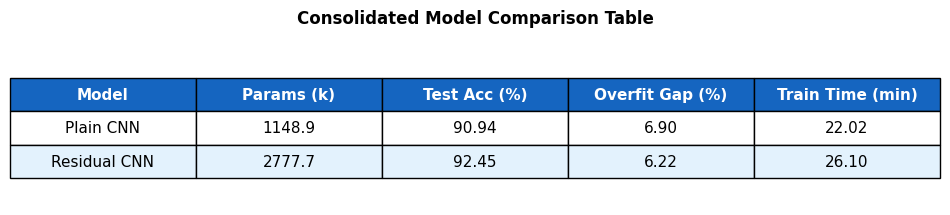

In [10]:
# ─────────────────────────────────────────────
# CELL 12: Consolidated Summary Table
# ─────────────────────────────────────────────

summary_data = {
    'Model':           ['Plain CNN',                          'Residual CNN'],
    'Params (k)':      [f'{count_params(plain_cnn)/1000:.1f}', f'{count_params(res_cnn)/1000:.1f}'],
    'Test Acc (%)':    [f'{plain_test_acc:.2f}',               f'{res_test_acc:.2f}'],
    'Overfit Gap (%)': [f'{plain_gap:.2f}',                    f'{res_gap:.2f}'],
    'Train Time (min)':[f"{plain_history['training_time_min']:.2f}", f"{res_history['training_time_min']:.2f}"]
}

fig, ax = plt.subplots(figsize=(10, 2))
ax.axis('off')
col_labels = list(summary_data.keys())
row_data   = list(zip(*summary_data.values()))
tbl = ax.table(cellText=row_data, colLabels=col_labels,
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1.2, 2)
for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#1565C0')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
for i in range(1, len(row_data)+1):
    c = '#E3F2FD' if i % 2 == 0 else 'white'
    for j in range(len(col_labels)):
        tbl[i, j].set_facecolor(c)

plt.title('Consolidated Model Comparison Table', fontweight='bold', pad=20)
plt.show()

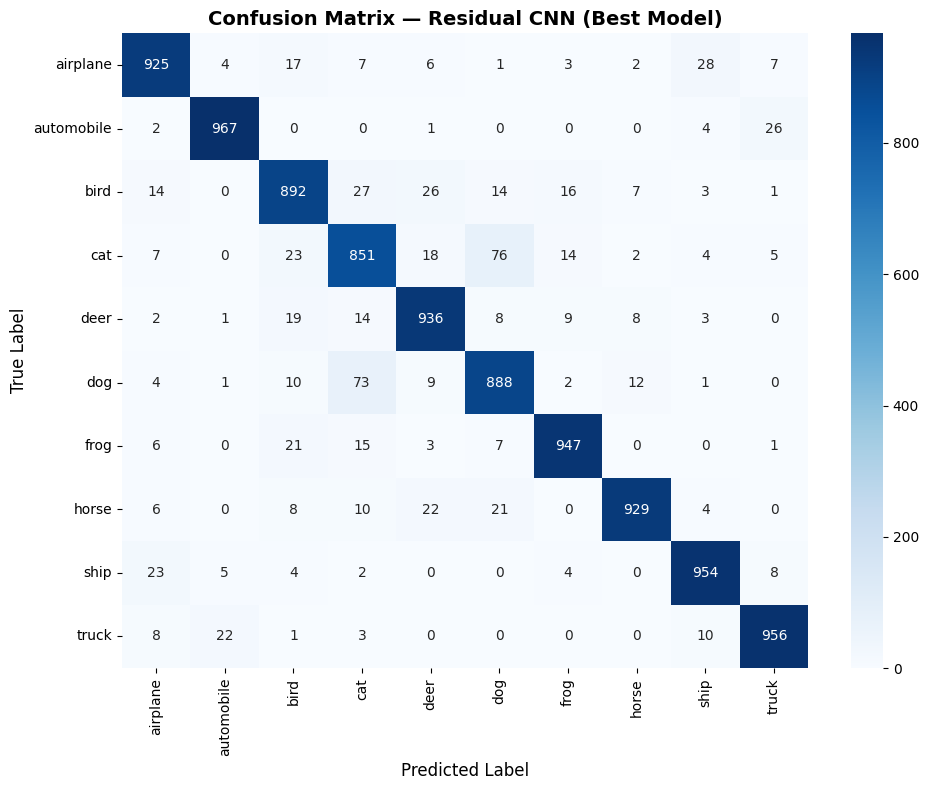

In [11]:
# confusin matrix
cm = confusion_matrix(res_labels, res_preds)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CIFAR10_CLASSES,
            yticklabels=CIFAR10_CLASSES,
            ax=ax)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.set_title('Confusion Matrix — Residual CNN (Best Model)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Classification Report — Residual CNN
              precision    recall  f1-score   support

    airplane       0.93      0.93      0.93      1000
  automobile       0.97      0.97      0.97      1000
        bird       0.90      0.89      0.89      1000
         cat       0.85      0.85      0.85      1000
        deer       0.92      0.94      0.93      1000
         dog       0.87      0.89      0.88      1000
        frog       0.95      0.95      0.95      1000
       horse       0.97      0.93      0.95      1000
        ship       0.94      0.95      0.95      1000
       truck       0.95      0.96      0.95      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000



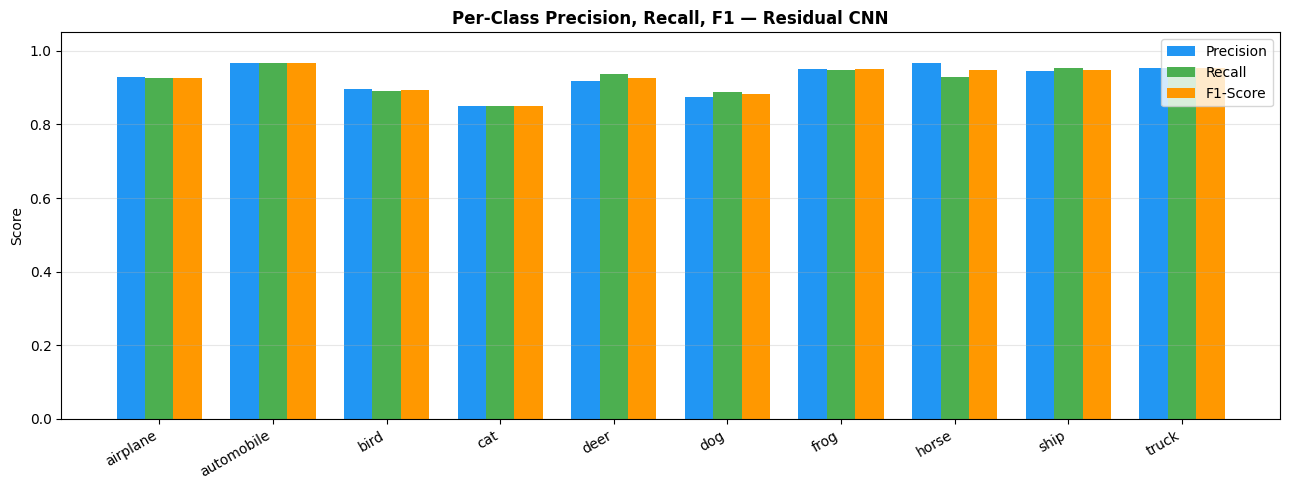

In [12]:
# precision, accuracy, f1 score
print("=" * 60)
print("Classification Report — Residual CNN")
print("=" * 60)
print(classification_report(res_labels, res_preds, target_names=CIFAR10_CLASSES))

# Bar chart of per-class F1
precision, recall, f1, _ = precision_recall_fscore_support(
    res_labels, res_preds, average=None
)

x = np.arange(len(CIFAR10_CLASSES))
width = 0.25
fig, ax = plt.subplots(figsize=(13, 5))
ax.bar(x - width, precision, width, label='Precision', color='#2196F3')
ax.bar(x,         recall,    width, label='Recall',    color='#4CAF50')
ax.bar(x + width, f1,        width, label='F1-Score',  color='#FF9800')
ax.set_xticks(x); ax.set_xticklabels(CIFAR10_CLASSES, rotation=30, ha='right')
ax.set_ylabel('Score'); ax.set_ylim(0, 1.05)
ax.set_title('Per-Class Precision, Recall, F1 — Residual CNN', fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

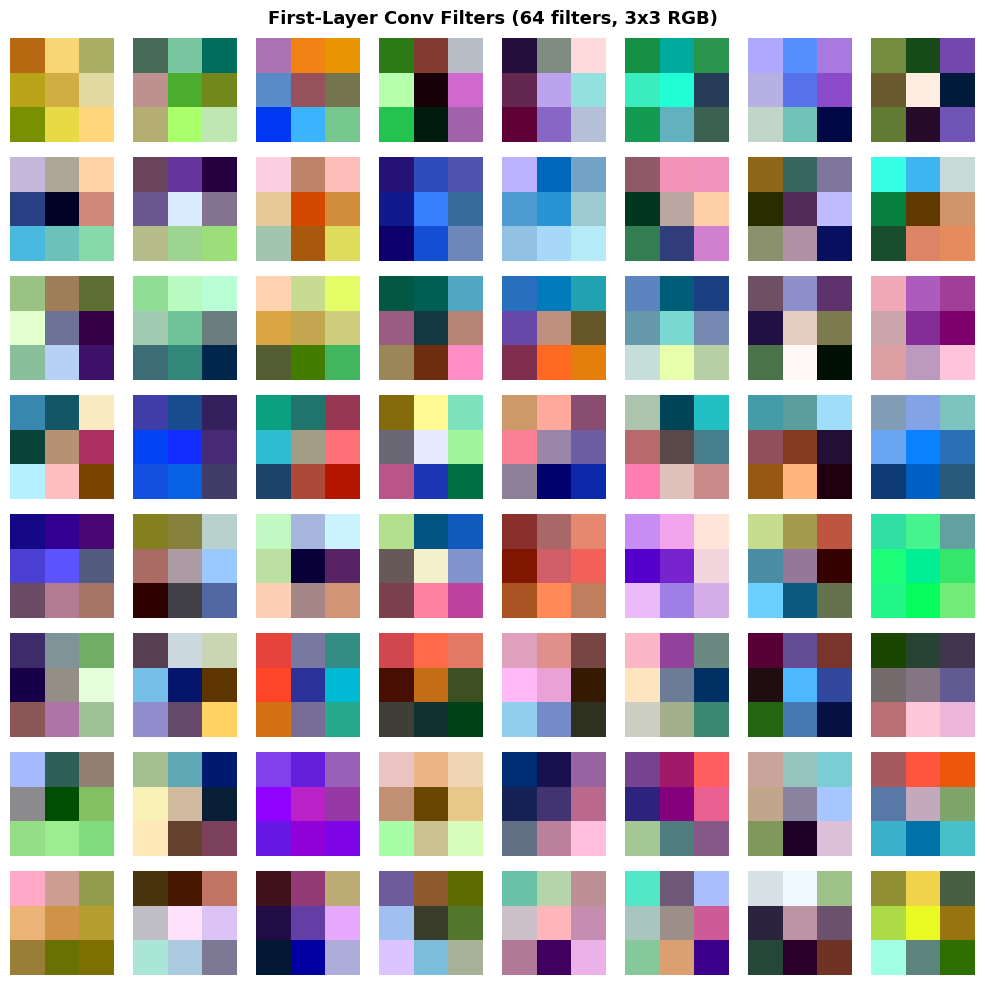

In [13]:
# First grid layerr
first_weights = res_cnn.stem[0].weight.data.cpu().clone()  # shape: (64, 3, 3, 3)

# Normalize each filter to [0,1] for display
def normalize_filter(f):
    f = f - f.min()
    return f / (f.max() + 1e-8)

fig, axes = plt.subplots(8, 8, figsize=(10, 10))
fig.suptitle('First-Layer Conv Filters (64 filters, 3x3 RGB)', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < first_weights.shape[0]:
        filt = normalize_filter(first_weights[i]).permute(1, 2, 0).numpy()
        ax.imshow(filt)
    ax.axis('off')

plt.tight_layout()
plt.savefig('first_layer_filters.png', dpi=150, bbox_inches='tight')
plt.show()

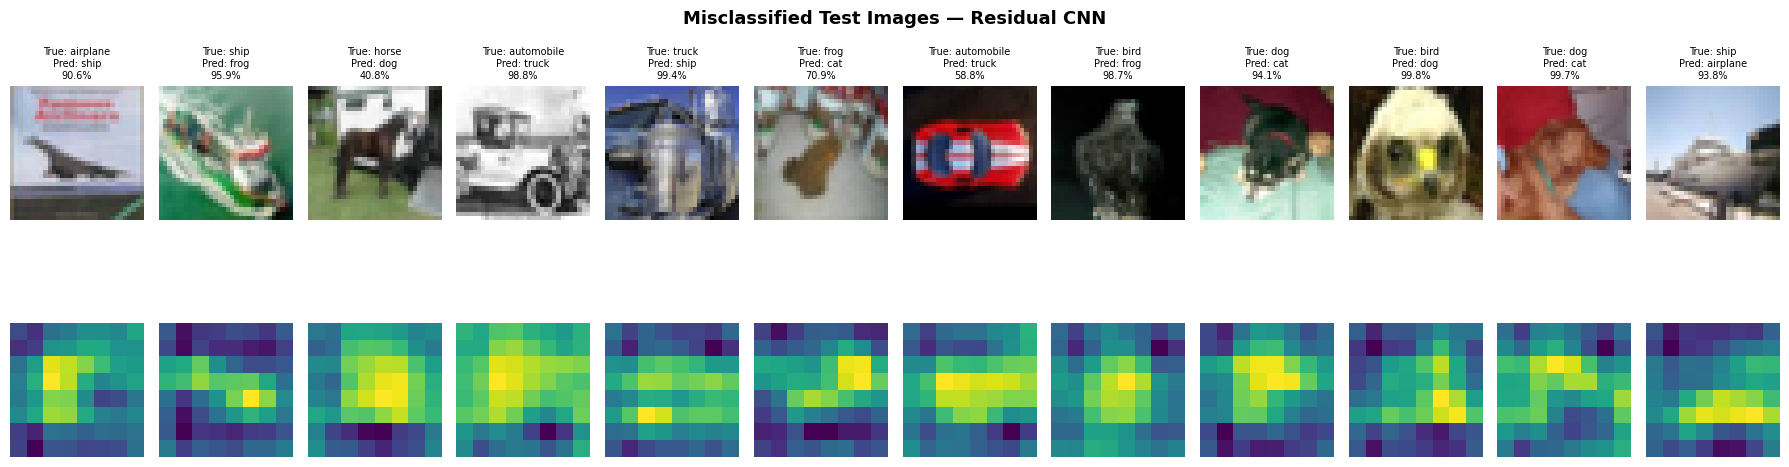

In [14]:
# Misscalssified images with feature maps
feature_maps = {}
def hook_fn(module, input, output):
    feature_maps['last_conv'] = output.detach()

# Register hook on last residual block's second conv
hook = res_cnn.stage3[1].conv2.register_forward_hook(hook_fn)

# Collect misclassified images
misclassified = []
res_cnn.eval()

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(DEVICE), labels.to(DEVICE)
        outputs = res_cnn(inputs)
        probs   = F.softmax(outputs, dim=1)
        conf, predicted = probs.max(1)

        wrong_idx = (predicted != labels).nonzero(as_tuple=True)[0]
        for idx in wrong_idx:
            if len(misclassified) >= 12:
                break
            # Get feature map for this sample
            single_input = inputs[idx:idx+1]
            single_out   = res_cnn(single_input)
            fmap = feature_maps['last_conv'][0].mean(0).cpu().numpy()  # average across channels

            misclassified.append({
                'image':      inputs[idx].cpu(),
                'true':       labels[idx].item(),
                'pred':       predicted[idx].item(),
                'conf':       conf[idx].item(),
                'fmap':       fmap
            })
        if len(misclassified) >= 12:
            break

hook.remove()  # Always remove hooks after use

# --- Plot misclassified images ---
CIFAR_MEAN = torch.tensor(MEAN).view(3,1,1)
CIFAR_STD  = torch.tensor(STD).view(3,1,1)

def denormalize(tensor):
    return (tensor * CIFAR_STD + CIFAR_MEAN).clamp(0, 1).permute(1, 2, 0).numpy()

fig = plt.figure(figsize=(18, 10))
fig.suptitle('Misclassified Test Images — Residual CNN',
             fontsize=13, fontweight='bold')

for i, item in enumerate(misclassified[:12]):
    # Original image
    ax1 = fig.add_subplot(4, 12, i + 1)
    ax1.imshow(denormalize(item['image']))
    ax1.set_title(f"True: {CIFAR10_CLASSES[item['true']]}\nPred: {CIFAR10_CLASSES[item['pred']]}\n{item['conf']*100:.1f}%",
                  fontsize=7)
    ax1.axis('off')

    # Feature map
    ax2 = fig.add_subplot(4, 12, i + 13)
    ax2.imshow(item['fmap'], cmap='viridis')
    ax2.axis('off')

plt.tight_layout()
plt.savefig('misclassified_images.png', dpi=150, bbox_inches='tight')
plt.show()